# 09b. The RL Loop & GRPO — what LLM RL inherits from control RL

**Tier:** Training
**Estimated time:** 60 minutes
**Prerequisites:** 01, 07, 08, 09
**Priority:** 🟡 Important — it is the substrate under GRPO/RLVR that notebook 09 skips: 09 teaches the *objective* (reward models, PPO's KL leash, DPO) but never the *machinery* — episodes, rollouts, advantage estimation, and why you bootstrap on truncation but not on termination. *If skipped, revisit when:* before working on RL-based post-training, or an RL-flavoured infra role.
**Source material:** Stanford LLM curriculum, Lecture 6 — "LLM reasoning: reasoning models, RL for reasoning, GRPO, scaling" (https://x.com/ajitcodes/status/2057043965317165490). Primary papers: GAE (Schulman et al., arXiv:1506.02438), PPO (Schulman et al., arXiv:1707.06347), *Time Limits in Reinforcement Learning* (Pardo et al., arXiv:1712.00378), and GRPO as introduced in DeepSeekMath (Shao et al., arXiv:2402.03300).

## What You'll Learn
- The **RL loop** — `reset()` / `step(action)` / observation / reward / `terminated` / `truncated` — and how a **batched (vectorized)** env changes the shapes and hides an auto-reset trap
- Why **`terminated` and `truncated` are not the same flag**, demonstrated numerically: collapsing them into one `done` biases the learned value function by more than 2x on a toy MDP
- **Returns → baselines → GAE(λ)** as an explicit bias/variance knob, and how **GRPO** throws the value network away by using the *group* as the baseline
- What actually transfers from control RL to **RLVR** LLM training — and, just as importantly, what does not

## Why This Matters
Notebook 09 taught you the alignment *objective*: a reward model, PPO with a KL leash, and DPO as the shortcut. It never showed you the loop that PPO actually runs inside. That gap matters now, because the reasoning-model era runs on **GRPO** over verifiable rewards, and GRPO is defined by what it *removes* from a standard actor-critic setup — a value network, a per-token critic, a bootstrapped advantage. You cannot reason about what was removed without knowing what was there.

In [1]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook — it runs fully offline on CPU with NumPy + matplotlib.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import numpy as np
np.random.seed(0)

## A note on scope

This repository is deliberately scoped to the LLM / agent-engineering lane, and reinforcement
learning as a field was never part of it. This notebook is the one exception, and it earns its
place by being *narrow*: everything below exists only to make GRPO and RLVR legible.

Notebook **09** covers reward models, PPO-for-alignment, and DPO. What it skips is the plumbing
PPO sits on top of — the environment interface, episodes and rollouts, and advantage estimation.
GRPO inherits that plumbing, discards half of it, and the discarding is the whole point. So this
notebook teaches the machinery, then shows exactly which pieces survive the trip to an LLM.

There is no Tier for control RL here, and there will not be one. If you want the field itself,
read Sutton & Barto. If you want to read a GRPO training script without guessing, read this.

## 1. The loop

Supervised learning has one shape: `(x, y)` pairs drawn i.i.d. from a dataset. RL has a different
one, and every RL codebase you will ever open is a variation on it:

```
obs = env.reset()                       # start a new episode
while True:
    action = policy(obs)                # the thing you are training
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break                           # episode over
```

Five nouns, and they are the whole vocabulary:

- **environment** — the thing that holds state and reacts. You do not train it.
- **observation** — what the policy is allowed to see this step.
- **action** — what the policy emits.
- **reward** — a scalar the environment hands back per step. Not a loss. You *maximize* it.
- **episode** — one `reset()` → done. The unit of experience, and the analogue of one training example.

The **policy** is a function from observation to action. In control RL it is a small MLP. In LLM RL
it is the language model itself, and an "action" is a token.

The one structural difference from supervised learning: your data distribution depends on your
current parameters. Change the policy and you change which states you ever see. Everything awkward
about RL follows from that sentence.

### The toy environment

We need something small enough to have an *exactly computable* answer, because otherwise the
numerical claims later in this notebook would just be assertions. So: a five-cell corridor.

Position 0 is a **drain** — reach it and the episode genuinely ends, forever, with no further
reward. Positions 1–4 are alive and pay **+1 for every step you survive**. Position 4 has a wall.
You always start at position 1, and you take one step left or right per timestep.

There is also a **time limit of 8 steps**, which is *not part of the world* — it is a bookkeeping
decision we made so the loop returns. Hold on to that distinction; section 3 is entirely about it.

In [2]:
GAMMA = 0.95          # discount factor
N_POS = 5             # positions 0..4 ; position 0 is the drain
P_RIGHT = 0.6         # our fixed policy: step right 60% of the time
START = 1             # every episode starts here
TIME_LIMIT = 8        # a BOOKKEEPING limit, not a fact about the world


class Corridor:
    # A 5-cell corridor. Action 0 = step left, 1 = step right (position 4 has a wall).
    # Reward +1 for every step that leaves you alive; 0 for the step into the drain.
    #
    # step() returns the modern 5-tuple: (obs, reward, terminated, truncated, info).
    #   terminated -> the MDP genuinely ended (fell in the drain). No future exists.
    #   truncated  -> we hit OUR time limit. The world would happily have continued.

    def __init__(self, seed=0, time_limit=TIME_LIMIT):
        self.rng = np.random.default_rng(seed)
        self.time_limit = time_limit

    def reset(self):
        self.pos = START
        self.t = 0
        return self.pos                       # observation = the position

    def step(self, action):
        self.t += 1
        self.pos = min(self.pos + (1 if action == 1 else -1), N_POS - 1)   # wall at N_POS-1
        terminated = self.pos == 0                                          # fell in the drain
        reward = 0.0 if terminated else 1.0                                 # +1 for surviving
        truncated = (not terminated) and (self.t >= self.time_limit)        # out of time
        return self.pos, reward, terminated, truncated, {}


def policy(rng):
    # A fixed stochastic policy. We are NOT training it yet — sections 1-4 are about
    # estimating values and advantages for a policy that is already given.
    return int(rng.random() < P_RIGHT)


print(f"corridor: positions 0..{N_POS - 1}, drain at 0, wall at {N_POS - 1}, time limit {TIME_LIMIT}")

corridor: positions 0..4, drain at 0, wall at 4, time limit 8


In [3]:
# Two episodes, printed step by step. This IS the loop from the markdown above.
# The two seeds are picked so you see one of each ending -- they are the same loop.
for seed in (0, 3):
    rng = np.random.default_rng(seed)
    env = Corridor(seed=seed)

    obs = env.reset()
    print(f"--- episode (seed {seed}) ---   reset -> obs={obs}")
    print(f"{'t':>2}  {'action':>6}  {'obs':>3}  {'reward':>6}  {'terminated':>10}  {'truncated':>9}")
    total = 0.0
    for t in range(TIME_LIMIT + 1):
        action = policy(rng)
        obs, reward, terminated, truncated, info = env.step(action)
        total += reward
        name = 'right' if action else 'left'
        print(f"{t:>2}  {name:>6}  {obs:>3}  {reward:>6.1f}  "
              f"{str(terminated):>10}  {str(truncated):>9}")
        if terminated or truncated:
            break

    ending = "TERMINATION (fell in the drain)" if terminated else "TRUNCATION (hit our time limit)"
    print(f"ended after {t + 1} steps by {ending}; undiscounted return = {total}\n")

--- episode (seed 0) ---   reset -> obs=1
 t  action  obs  reward  terminated  truncated
 0    left    0     0.0        True      False
ended after 1 steps by TERMINATION (fell in the drain); undiscounted return = 0.0

--- episode (seed 3) ---   reset -> obs=1
 t  action  obs  reward  terminated  truncated
 0   right    2     1.0       False      False
 1   right    3     1.0       False      False
 2    left    2     1.0       False      False
 3   right    3     1.0       False      False
 4   right    4     1.0       False      False
 5   right    4     1.0       False      False
 6   right    4     1.0       False      False
 7   right    4     1.0       False       True
ended after 8 steps by TRUNCATION (hit our time limit); undiscounted return = 8.0



## 2. Batched (vectorized) environments

One environment stepping one action at a time will not keep a GPU busy. Every real training loop
runs **N environments in lockstep**: you hand it a vector of N actions, it hands you back vectors of
N observations, N rewards, N flags. Nothing about the algorithm changes; every scalar just grows a
leading batch dimension.

| | single env | vectorized env (N envs) |
|---|---|---|
| `reset()` → obs | scalar / `(obs_dim,)` | `(N,)` / `(N, obs_dim)` |
| `step(action)` takes | one action | `(N,)` actions |
| returns reward | scalar | `(N,)` |
| returns terminated / truncated | bool | `(N,)` bool arrays |

Here is the part that bites people. The N environments finish at **different times**. If the vector
env stopped and waited for the slowest one, you would waste most of your batch. So it doesn't wait —
it **auto-resets**: the instant env `i` is done, it silently starts a new episode and the observation
at index `i` is the *new episode's first observation*, not the one that ended the old episode.

The true final observation is not thrown away. By convention it is stashed in the info dict:
`info["final_observation"][i]`.

**Why getting this wrong corrupts training instead of crashing it.** Both observations are the same
dtype and the same shape. A transition built from the post-reset observation is perfectly
well-formed — it is just a transition that never happened. Nothing raises. Your loss goes down.
Your returns are quietly wrong, and they stay wrong for the entire run.

In [4]:
class VecCorridor:
    # N independent Corridors stepped in lockstep, with the standard AUTO-RESET convention:
    # when env i finishes, obs[i] is the NEXT episode's first observation, and the true
    # final observation of the episode that just ended is put in info['final_observation'][i].

    def __init__(self, n_envs, seed=0, time_limit=TIME_LIMIT):
        self.n_envs = n_envs
        self.envs = [Corridor(seed=seed + i, time_limit=time_limit) for i in range(n_envs)]

    def reset(self):
        return np.array([e.reset() for e in self.envs], dtype=int)

    def step(self, actions):
        obs = np.zeros(self.n_envs, dtype=int)
        rew = np.zeros(self.n_envs, dtype=float)
        term = np.zeros(self.n_envs, dtype=bool)
        trunc = np.zeros(self.n_envs, dtype=bool)
        final = np.full(self.n_envs, -1, dtype=int)      # -1 = this env did not finish

        for i, (e, a) in enumerate(zip(self.envs, actions)):
            o, r, te, tr, _ = e.step(int(a))
            if te or tr:
                final[i] = o                              # the observation that ACTUALLY ended it
                o = e.reset()                             # ...and now we are already elsewhere
            obs[i], rew[i], term[i], trunc[i] = o, r, te, tr

        return obs, rew, term, trunc, {"final_observation": final}


venv = VecCorridor(n_envs=4, seed=11)
obs = venv.reset()
print("obs        ", obs, obs.shape)
actions = np.array([1, 1, 0, 1])
obs, rew, term, trunc, info = venv.step(actions)
print("obs        ", obs, obs.shape)
print("reward     ", rew, rew.shape)
print("terminated ", term, term.shape)
print("truncated  ", trunc, trunc.shape)
print("info['final_observation']", info["final_observation"])

obs         [1 1 1 1] (4,)
obs         [2 2 1 2] (4,)
reward      [1. 1. 0. 1.] (4,)
terminated  [False False  True False] (4,)
truncated   [False False False False] (4,)
info['final_observation'] [-1 -1  0 -1]


In [5]:
# The trap, made visible. Run 8 vectorized envs until several finish, and print the two
# observations side by side: the one the vec env HANDED you, and the one that actually
# ended the episode. Note that nothing about the returned obs looks wrong.
venv = VecCorridor(n_envs=8, seed=21)
obs = venv.reset()
rng = np.random.default_rng(21)

terminations, truncations = [], []
for t in range(3 * TIME_LIMIT):
    prev = obs.copy()
    actions = (rng.random(venv.n_envs) < P_RIGHT).astype(int)
    obs, rew, term, trunc, info = venv.step(actions)
    for i in range(venv.n_envs):
        if term[i] or trunc[i]:
            row = (t, i, prev[i], obs[i], info["final_observation"][i])
            (terminations if term[i] else truncations).append(row)

print(f"{'step':>4} {'env':>4} {'obs_before':>11} {'obs_returned':>13} {'final_obs':>10}  ending")
for row in terminations[:4]:
    print(f"{row[0]:>4} {row[1]:>4} {row[2]:>11} {row[3]:>13} {row[4]:>10}  TERMINATED (drain)")
for row in truncations[:4]:
    print(f"{row[0]:>4} {row[1]:>4} {row[2]:>11} {row[3]:>13} {row[4]:>10}  TRUNCATED (time limit)")

print("\nEvery 'obs_returned' above is a fresh episode's start state, not the one that ended the episode.")
print("On a TERMINATED row it does not matter -- you must not bootstrap through a real ending anyway.")
print("On a TRUNCATED row it is the bug: V(obs_returned) is a legal number, it is the wrong")
print("number, and nothing anywhere will tell you.")

step  env  obs_before  obs_returned  final_obs  ending
   0    0           1             1          0  TERMINATED (drain)
   0    1           1             1          0  TERMINATED (drain)
   0    2           1             1          0  TERMINATED (drain)
   0    4           1             1          0  TERMINATED (drain)
   7    7           4             1          3  TRUNCATED (time limit)
   8    5           3             1          4  TRUNCATED (time limit)
   9    0           2             1          3  TRUNCATED (time limit)
   9    1           4             1          4  TRUNCATED (time limit)

Every 'obs_returned' above is a fresh episode's start state, not the one that ended the episode.
On a TERMINATED row it does not matter -- you must not bootstrap through a real ending anyway.
On a TRUNCATED row it is the bug: V(obs_returned) is a legal number, it is the wrong
number, and nothing anywhere will tell you.


**TODO (Itai):** the auto-reset trap as you actually hit it — what the two simulators disagreed about, and how you found it.

## 3. `terminated` vs `truncated` — the centerpiece

Two flags, two completely different facts about the world:

- **`terminated`** — the MDP ended. There is no future state and no future reward. The correct value
  of "what comes next" is exactly **0**, and that zero is *ground truth*, not an approximation.
- **`truncated`** — *you* stopped collecting. The world was mid-sentence. The future still exists;
  you simply are not going to look at it. The correct value of "what comes next" is
  **V(s_final)** — your current best estimate.

So the bootstrapping rule, which is the single most-copied-wrong line in RL code:

```
target = reward + gamma * V(next_state) * (1 - terminated)     # correct
target = reward + gamma * V(next_state) * (1 - done)           # WRONG — done = terminated or truncated
```

Collapsing them teaches the value function that hitting your own time limit is as catastrophic as
falling in the drain. The agent learns to fear the wall clock. This is the bug Pardo et al. wrote a
whole paper about (arXiv:1712.00378), and it is still everywhere.

Our corridor has an exactly solvable answer, so we do not have to take any of this on faith. For a
fixed policy the value function satisfies a linear system:

```
V(s) = sum_a  pi(a|s) * [ r(s,a) + gamma * V(s') ]        with V(drain) = 0
```

Four unknowns, four equations. Solve it, then compare against what TD(0) learns under three
different bootstrapping rules.

In [6]:
def true_values(gamma=GAMMA):
    # Solve V = r + gamma * P V exactly for our fixed policy (positions 1..4; V(0)=0 by definition).
    A = np.zeros((N_POS - 1, N_POS - 1))
    b = np.zeros(N_POS - 1)
    for s in range(1, N_POS):
        i = s - 1
        A[i, i] += 1.0
        for prob, nxt in ((1 - P_RIGHT, s - 1), (P_RIGHT, min(s + 1, N_POS - 1))):
            r = 0.0 if nxt == 0 else 1.0          # no reward for the step into the drain
            b[i] += prob * r
            if nxt != 0:                          # the drain contributes nothing: V(0) = 0
                A[i, nxt - 1] -= prob * gamma
    V = np.zeros(N_POS)
    V[1:] = np.linalg.solve(A, b)
    return V


V_TRUE = true_values()
print("exact V*(s) for the fixed policy, infinite horizon (no time limit — the world has none):")
for s in range(N_POS):
    label = "  <- drain, exactly 0" if s == 0 else ("  <- start state" if s == START else "")
    print(f"  V*({s}) = {V_TRUE[s]:6.3f}{label}")

exact V*(s) for the fixed policy, infinite horizon (no time limit — the world has none):
  V*(0) =  0.000  <- drain, exactly 0
  V*(1) =  7.006  <- start state
  V*(2) = 11.238
  V*(3) = 13.291
  V*(4) = 14.071


In [7]:
def td_learn(mode, total_steps=240_000, n_envs=8, seed=1):
    # Tabular TD(0) driven by a REAL vectorized env, so the auto-reset trap is the genuine
    # article rather than a simulation of it. Three bootstrapping rules:
    #   'correct'   -> bootstrap on truncation using info['final_observation']; never on termination
    #   'collapsed' -> the classic bug: zero the bootstrap whenever (terminated or truncated)
    #   'autoreset' -> bootstrap on truncation, but on the POST-RESET observation the vec env handed us
    venv = VecCorridor(n_envs, seed=seed)
    rng = np.random.default_rng(seed + 100)
    obs = venv.reset()
    V = np.zeros(N_POS)
    visits = np.zeros(N_POS)

    for _ in range(total_steps // n_envs):
        actions = (rng.random(n_envs) < P_RIGHT).astype(int)
        next_obs, rew, term, trunc, info = venv.step(actions)

        for i in range(n_envs):
            done = term[i] or trunc[i]
            if mode == "autoreset":
                s_next = next_obs[i]                      # BUG: a fresh episode's start state
            else:
                s_next = info["final_observation"][i] if done else next_obs[i]

            if mode == "collapsed":
                boot = 0.0 if done else GAMMA * V[s_next]     # BUG: truncation treated as the end of the world
            else:
                boot = 0.0 if term[i] else GAMMA * V[s_next]  # only TERMINATION zeroes the bootstrap

            s = obs[i]
            visits[s] += 1
            alpha = 1.0 / (1.0 + visits[s]) ** 0.7            # Robbins-Monro decay
            V[s] += alpha * (rew[i] + boot - V[s])

        obs = next_obs
    return V


learned = {m: td_learn(m) for m in ("correct", "collapsed", "autoreset")}

print(f"{'state':>5} {'V* (exact)':>11} {'correct':>9} {'collapsed done':>15} {'auto-reset bug':>15}")
for s in range(1, N_POS):
    print(f"{s:>5} {V_TRUE[s]:>11.3f} {learned['correct'][s]:>9.3f} "
          f"{learned['collapsed'][s]:>15.3f} {learned['autoreset'][s]:>15.3f}")

print()
for m, V in learned.items():
    rmse = float(np.sqrt(np.mean((V[1:] - V_TRUE[1:]) ** 2)))
    print(f"  RMSE vs exact V*  [{m:>9}] = {rmse:6.3f}")

state  V* (exact)   correct  collapsed done  auto-reset bug
    1       7.006     6.905           3.175           4.534
    2      11.238    11.134           4.573           6.965
    3      13.291    13.198           4.851           7.765
    4      14.071    13.978           4.323           7.613

  RMSE vs exact V*  [  correct] =  0.098
  RMSE vs exact V*  [collapsed] =  7.506
  RMSE vs exact V*  [autoreset] =  4.915


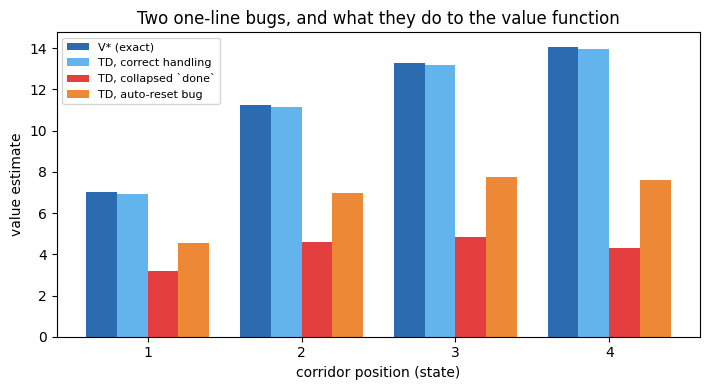

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

states = np.arange(1, N_POS)
width = 0.2
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.bar(states - 1.5 * width, V_TRUE[1:], width, label="V* (exact)", color="#2b6cb0")
ax.bar(states - 0.5 * width, learned["correct"][1:], width, label="TD, correct handling", color="#63b3ed")
ax.bar(states + 0.5 * width, learned["collapsed"][1:], width, label="TD, collapsed `done`", color="#e53e3e")
ax.bar(states + 1.5 * width, learned["autoreset"][1:], width, label="TD, auto-reset bug", color="#ed8936")
ax.set_xticks(states)
ax.set_xlabel("corridor position (state)")
ax.set_ylabel("value estimate")
ax.set_title("Two one-line bugs, and what they do to the value function")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

*The blue pair is the control: handle `terminated` and `truncated` separately and tabular TD
recovers the exact value function. Collapse them into one `done` (red) and every state is learned at
roughly a third of its true value — the agent has been taught that running out of wall-clock is as
final as death. Bootstrap on the post-reset observation instead (orange) and you get a different
wrong answer, pulled toward the value of the start state. Neither bug raises an exception; both
produce a loss curve that goes down.*

**TODO (Itai):** what the terminated-vs-truncated bug looked like in practice — the symptom you saw before you knew the cause.

## 4. Returns, baselines, and GAE(λ)

**Return.** The thing we actually care about is not this step's reward but the discounted sum of all
of them from here on: `G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + …`. γ < 1 makes the sum finite and
encodes "sooner is better."

**Advantage.** The policy gradient does not want the return; it wants to know whether an action was
*better than usual* from that state: `A(s,a) = Q(s,a) − V(s)`. Positive → make it more likely.
Negative → less. Subtracting `V(s)` — the **baseline** — does not change the gradient in expectation
(it is a constant with respect to the action), but it enormously reduces the variance. Without it,
in an environment where every return is large and positive, every action gets pushed up and the
learning signal is buried in noise. This one fact is the entire seed of GRPO.

**GAE(λ)** interpolates between two ways of estimating that advantage:

- λ = 0 → `A = r + γV(s') − V(s)`. One real reward, then trust the critic. **Low variance, high bias**
  (it inherits every error in your critic).
- λ = 1 → `A = G_t − V(s)`. All real rewards, trust the critic only at the very end. **Unbiased, high
  variance** (one lucky episode moves the estimate a lot).

In between: `A = Σ_t (γλ)^t · δ_t` where `δ_t = r_t + γV(s_{t+1}) − V(s_t)`.

Below we measure both halves of that tradeoff instead of asserting them. We know the exact advantage
of taking `right` from the start state, so bias is computable. We give the estimator a deliberately
imperfect critic (`V̂ = V* + noise`, the same 20 draws reused at every λ so the curves are paired),
and sweep λ.

Note the `(1 - terminated)` in `gae()` below — section 3 is not a separate lesson, it is a line inside
this function.

In [9]:
# Collect rollouts ONCE. The policy is fixed, so the trajectories do not depend on the critic;
# every (lambda, critic) pair below is scored against the same 2000 episodes.
# Each episode starts at START and is FORCED to take 'right' first, so we are estimating the
# advantage of one specific (state, action) pair whose exact value we can compute.
rng = np.random.default_rng(7)
env = Corridor(seed=7)
EPISODES = []
for _ in range(2000):
    s = env.reset()
    traj, forced = [], 1
    while True:
        a = forced if forced is not None else int(rng.random() < P_RIGHT)
        forced = None
        s2, r, term, trunc, _ = env.step(a)
        traj.append((s, r, s2, term, trunc))
        if term or trunc:
            break
        s = s2
    EPISODES.append(traj)

# The exact advantage of 'right' from the start state: A*(s,a) = r + gamma*V*(s') - V*(s)
A_STAR = 1.0 + GAMMA * V_TRUE[START + 1] - V_TRUE[START]
print(f"exact A*(start={START}, right) = {A_STAR:.4f}")
print(f"{len(EPISODES)} episodes, mean length {np.mean([len(e) for e in EPISODES]):.2f}, "
      f"truncation rate {np.mean([e[-1][4] for e in EPISODES]):.1%}")


def gae(traj, Vhat, lam, gamma=GAMMA):
    # A = sum_t (gamma*lam)^t * delta_t,  delta_t = r + gamma*V(s')*(1-terminated) - V(s)
    # The (1-terminated) is the ONLY place termination and truncation are distinguished --
    # and it is exactly the distinction section 3 was about.
    adv, coef = 0.0, 1.0
    for (s, r, s2, term, trunc) in traj:
        boot = 0.0 if term else gamma * Vhat[s2]
        adv += coef * (r + boot - Vhat[s])
        coef *= gamma * lam
    return adv

exact A*(start=1, right) = 4.6704
2000 episodes, mean length 6.86, truncation rate 69.6%


In [10]:
# 20 imperfect critics, drawn once and reused at every lambda so the sweep is paired.
crit_rng = np.random.default_rng(3)
CRITICS = []
for _ in range(20):
    Vh = V_TRUE + crit_rng.normal(0, 2.0, size=N_POS)
    Vh[0] = 0.0            # the terminal state's value is known exactly; a critic never gets this wrong
    CRITICS.append(Vh)

lams = np.linspace(0, 1, 11)
bias, variance = [], []
for lam in lams:
    bs, vs = [], []
    for Vh in CRITICS:
        est = np.array([gae(t, Vh, lam) for t in EPISODES])
        bs.append(abs(est.mean() - A_STAR))     # |bias|: how far the AVERAGE estimate sits from truth
        vs.append(est.var())                    # variance: how much one episode's estimate jumps around
    bias.append(np.mean(bs))
    variance.append(np.mean(vs))

print(f"{'lambda':>7} {'|bias|':>8} {'variance':>10}")
for lam, b, v in zip(lams, bias, variance):
    print(f"{lam:>7.1f} {b:>8.3f} {v:>10.3f}")

 lambda   |bias|   variance
    0.0    2.627      0.000
    0.1    2.469      0.094
    0.2    2.331      0.378
    0.3    2.237      0.883
    0.4    2.164      1.681
    0.5    2.105      2.894
    0.6    2.056      4.723
    0.7    2.018      7.523
    0.8    1.986     11.976
    0.9    1.958     19.553
    1.0    1.926     33.666


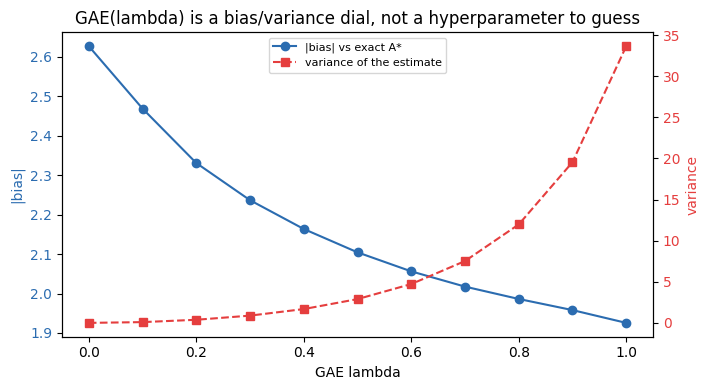

In [11]:
fig, ax1 = plt.subplots(figsize=(7.2, 4))
ax1.plot(lams, bias, "o-", color="#2b6cb0", label="|bias| vs exact A*")
ax1.set_xlabel("GAE lambda")
ax1.set_ylabel("|bias|", color="#2b6cb0")
ax1.tick_params(axis="y", labelcolor="#2b6cb0")

ax2 = ax1.twinx()
ax2.plot(lams, variance, "s--", color="#e53e3e", label="variance of the estimate")
ax2.set_ylabel("variance", color="#e53e3e")
ax2.tick_params(axis="y", labelcolor="#e53e3e")

ax1.set_title("GAE(lambda) is a bias/variance dial, not a hyperparameter to guess")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper center", fontsize=8)
plt.tight_layout()
plt.show()

*Left axis: bias falls monotonically as λ rises, because the estimator leans less on an imperfect
critic. Right axis: variance climbs from exactly zero at λ=0 (with the first action forced, that
estimate is deterministic) to ~34 at λ=1, where a single lucky episode swings the whole estimate.
λ≈0.95 is the usual default because it is far enough right to shed most of the critic's bias while
the variance is still payable.*

## 5. From policy gradient to PPO's clipped objective

With advantages in hand the policy gradient is one line:

```
grad = E[ A(s,a) * grad log pi(a|s) ]
```

Push up the log-probability of actions that beat the baseline; push down the ones that don't. That
is REINFORCE, and on its own it is fragile: one big gradient step moves the policy so far that the
data you collected — which came from the *old* policy — no longer describes the policy you now have.

PPO's fix is to optimize a surrogate in terms of the **probability ratio**
`ρ = π_new(a|s) / π_old(a|s)`, and to **clip** it:

```
L_CLIP = min( rho * A,  clip(rho, 1-eps, 1+eps) * A )
```

The `min` makes the objective **pessimistic**: when A > 0 the gain stops accruing past `1+ε`, so
there is no reward for lunging; when A < 0 the penalty is *not* capped below `1−ε`, so backing away
from a bad action is never discouraged. The effect is a trust region enforced with a clamp instead of
a constraint solver.

Notebook **09** already covered why PPO for alignment additionally carries a KL penalty to the SFT
reference — that is a different leash, on the *policy* rather than the *step size*, and it is not
re-derived here.

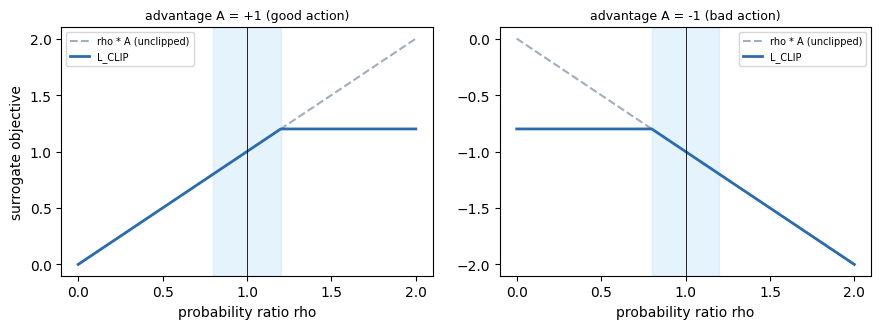

In [12]:
eps = 0.2
ratio = np.linspace(0.0, 2.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=False)
for ax, A, title in zip(axes, (1.0, -1.0), ("advantage A = +1 (good action)",
                                            "advantage A = -1 (bad action)")):
    unclipped = ratio * A
    clipped = np.clip(ratio, 1 - eps, 1 + eps) * A
    ax.plot(ratio, unclipped, "--", color="#a0aec0", label="rho * A (unclipped)")
    ax.plot(ratio, np.minimum(unclipped, clipped), color="#2b6cb0", lw=2, label="L_CLIP")
    ax.axvspan(1 - eps, 1 + eps, color="#bee3f8", alpha=0.4)
    ax.axvline(1.0, color="k", lw=0.6)
    ax.set_xlabel("probability ratio rho")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
axes[0].set_ylabel("surrogate objective")
plt.tight_layout()
plt.show()

*Shaded band = the trust region `[1−ε, 1+ε]`. Left: with a positive advantage the objective flattens
past `1+ε` — pushing the action further gains nothing, so the update stops. Right: with a negative
advantage the objective keeps falling below `1−ε` rather than flattening — PPO never stops you from
walking away from a bad action. That asymmetry is the whole trick.*

## 6. GRPO — the group is the baseline

Everything above assumed a **critic**: a second network estimating V(s), trained alongside the policy,
supplying the baseline and the bootstrap. In the LLM setting that assumption is expensive and shaky:

1. **There is no reward until the end.** A verifier (unit tests, a math checker, a regex) reads the
   *finished* completion and returns one scalar. There is nothing to bootstrap on mid-sequence
   because there are no intermediate rewards to bootstrap toward.
2. **The critic would have to be a second LLM.** A value function over token-level states means a
   network the size of your policy, doubling memory and adding a second training loop.
3. **And it would be hard to fit anyway.** "How good is this half-written proof?" is a genuinely
   harder prediction problem than the one you are trying to solve — and a bad critic *injects* bias,
   as section 4's left axis showed.

**GRPO's move: get the baseline from siblings instead of from a network.** For each prompt, sample a
**group** of G completions. Score all G with the verifier. Then normalize *within the group*:

```
A_i = (r_i - mean(r_1..r_G)) / (std(r_1..r_G) + eps)
```

The group mean is the baseline. It is unbiased by construction (it is an empirical estimate of the
expected reward under the current policy for exactly this prompt), it costs G forward passes you were
going to spend on sampling anyway, and it deletes the value network entirely.

Below: the same toy task trained with a raw-reward policy gradient and with GRPO, each run twice —
once with the verifier returning 0/1, once with the *same* verifier shifted by a constant +5. A
constant offset carries no information whatsoever, so a correct algorithm should not notice it.

In [13]:
def run_group_rl(mode, offset, steps=300, n_prompts=6, K=8, G=8, lr=0.5, seed=0):
    # A deliberately tiny stand-in for LLM RL: each 'prompt' has K candidate 'completions',
    # exactly one of which the verifier accepts. The policy is a softmax over completions.
    # No environment dynamics, no intermediate rewards -- one terminal scalar per completion,
    # which is exactly the shape of RLVR.
    rng = np.random.default_rng(seed)
    correct = rng.integers(0, K, size=n_prompts)
    theta = np.zeros((n_prompts, K))
    acc_hist, dead_hist = [], []

    for _ in range(steps):
        grad = np.zeros_like(theta)
        dead = 0
        for p in range(n_prompts):
            z = theta[p] - theta[p].max()
            pi = np.exp(z); pi /= pi.sum()
            samples = rng.choice(K, size=G, p=pi)          # the GROUP: G completions for this prompt
            r = (samples == correct[p]).astype(float) + offset   # verifier score (+ a meaningless offset)

            if mode == "grpo":
                sd = r.std()
                if sd < 1e-8:                              # every completion scored the same ->
                    dead += 1                              # no within-group signal at all
                    adv = np.zeros(G)
                else:
                    adv = (r - r.mean()) / (sd + 1e-8)     # group-relative advantage
            else:
                adv = r                                    # raw reward, no baseline

            for i, k in enumerate(samples):
                onehot = np.zeros(K); onehot[k] = 1.0
                grad[p] += adv[i] * (onehot - pi) / G      # grad log pi(k) for a softmax = onehot - pi

        theta += lr * grad

        probs = []
        for p in range(n_prompts):
            z = theta[p] - theta[p].max(); pi = np.exp(z); pi /= pi.sum()
            probs.append(pi[correct[p]])
        acc_hist.append(np.mean(probs))
        dead_hist.append(dead / n_prompts)

    return np.array(acc_hist), np.array(dead_hist)


runs = {}
for mode in ("reinforce", "grpo"):
    for off in (0.0, 5.0):
        runs[(mode, off)] = run_group_rl(mode, off)

print(f"{'algorithm':>10} {'verifier offset':>16} {'final P(correct)':>18}")
for (mode, off), (acc, _) in runs.items():
    print(f"{mode:>10} {off:>16.0f} {acc[-1]:>18.3f}")

dead_grpo = runs[("grpo", 0.0)][1]
print(f"\nGRPO dead groups (every completion scored identically), last 50 steps: {dead_grpo[-50:].mean():.0%}")

 algorithm  verifier offset   final P(correct)
 reinforce                0              0.993
 reinforce                5              0.826
      grpo                0              0.998
      grpo                5              0.998

GRPO dead groups (every completion scored identically), last 50 steps: 97%


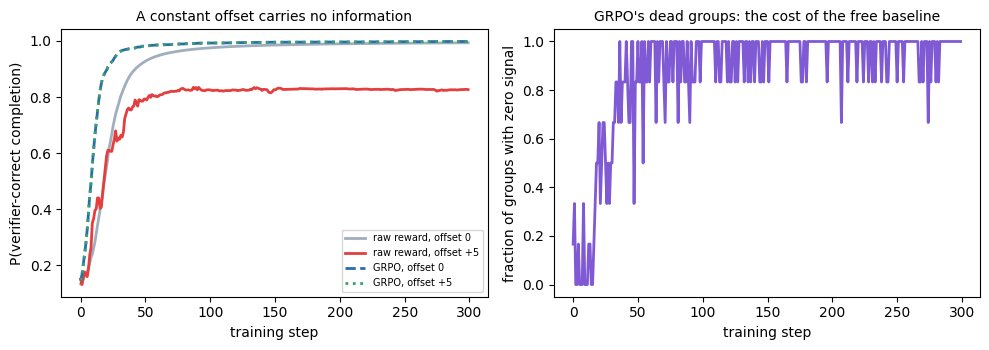

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

styles = {("reinforce", 0.0): ("#a0aec0", "-", "raw reward, offset 0"),
          ("reinforce", 5.0): ("#e53e3e", "-", "raw reward, offset +5"),
          ("grpo", 0.0): ("#2b6cb0", "--", "GRPO, offset 0"),
          ("grpo", 5.0): ("#38a169", ":", "GRPO, offset +5")}
for key, (color, ls, label) in styles.items():
    axes[0].plot(runs[key][0], color=color, ls=ls, lw=2, label=label)
axes[0].set_xlabel("training step"); axes[0].set_ylabel("P(verifier-correct completion)")
axes[0].set_title("A constant offset carries no information", fontsize=10)
axes[0].legend(fontsize=7, loc="lower right")

axes[1].plot(runs[("grpo", 0.0)][1], color="#805ad5", lw=2)
axes[1].set_xlabel("training step"); axes[1].set_ylabel("fraction of groups with zero signal")
axes[1].set_title("GRPO's dead groups: the cost of the free baseline", fontsize=10)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

*Left: the two GRPO curves lie exactly on top of each other, because subtracting the group mean makes
the update invariant to any constant added to the verifier — as it must be, since the constant says
nothing. The raw-reward run degrades visibly under the same offset: `+5` on every sample injects pure
noise into the gradient with no signal attached. Right: the price of the group baseline. As the policy
converges, nearly every group comes back all-correct, the within-group standard deviation collapses to
zero, and ~97% of groups contribute exactly nothing to the gradient. This is not a bug in our toy — it
is why real GRPO runs care so much about prompt difficulty curricula and dynamic sampling: a prompt
your policy always solves, or never solves, is a prompt you are burning G rollouts on for free.*

## 7. The bridge back to LLMs (RLVR)

**RLVR** — reinforcement learning from *verifiable* rewards — is what the reasoning-model era runs on.
No reward model, no human preference pairs: a program checks the answer and returns a scalar. Here is
the vocabulary map, stated honestly.

| Control RL | LLM RLVR | How good is the analogy? |
|---|---|---|
| environment | the prompt distribution | Weak. Prompts do not react to you. |
| initial state `s_0` | the prompt | Good. |
| action | one token | Structurally exact. |
| episode | one completion | Good — this is the cleanest correspondence. |
| `step()` transition | append the token to the context | Deterministic and known. There are no dynamics to learn. |
| reward | the verifier's score on the finished completion | Terminal only. Every intermediate reward is zero. |
| `terminated` | EOS emitted, or the verifier ran | Good. |
| `truncated` | hit `max_new_tokens` | Good — and this is exactly where section 3 comes back to bite. |
| policy | the language model | Good, modulo the policy having ~10^10 parameters. |
| value function `V(s)` | *usually absent* | This is precisely what GRPO deletes. |

### What does **not** transfer, and it matters

- **There is no environment.** The "transition function" is string concatenation. Nothing is
  stochastic except your own sampling. Half the difficulty of control RL — exploration, partial
  observability, non-stationary dynamics — simply does not exist here.
- **The discount factor mostly disappears.** With reward only at the end and episodes bounded by
  `max_new_tokens`, γ is usually 1. The intuition that γ trades off near versus far reward has
  nothing to trade off.
- **GAE(λ) usually disappears with it.** With no intermediate rewards and no critic, there is no
  multi-step estimator to interpolate. GRPO's advantage is a single scalar per completion, broadcast
  to every token in it. Section 4's dial exists in PPO-style LLM RL, not in vanilla GRPO.
- **Credit assignment is not solved, only hidden.** Broadcasting one terminal scalar across 2000
  tokens says "every token in this completion was equally responsible." That is obviously false. It
  works because the group baseline is *relatively* informative across siblings, not because the
  per-token attribution is right.
- **`truncated` is a real hazard, not a formality.** A completion cut off at `max_new_tokens` is not a
  wrong answer — it is an unfinished one. Scoring it 0 teaches the model that long reasoning is
  punished, which is precisely the opposite of what you want from a reasoning model. This is section
  3's bug wearing different clothes, and it is the most valuable thing this notebook has to give you.

## Exercises

In [15]:
# Exercise 1 (Warm-up): How big is the truncation bug, really?
# Task: Re-run td_learn('correct') and td_learn('collapsed') with TIME_LIMIT set to 4 and then to 30,
#       and report how the RMSE gap between them changes.
# Hint: Corridor takes a time_limit argument, and VecCorridor forwards it. Think about what fraction
#       of episodes end by truncation in each case before you look at the numbers.

# YOUR CODE HERE

In [16]:
# Exercise 2 (Apply): Leave-one-out instead of mean/std
# Task: Add a 'rloo' mode to run_group_rl that uses the leave-one-out baseline
#       A_i = r_i - mean(r_j for j != i)  -- no standard-deviation division at all.
#       Compare its learning curve and its dead-group fraction against GRPO's.
# Hint: mean of the others = (sum(r) - r_i) / (G - 1). Ask yourself which of the two is still
#       invariant to a constant offset, and which one still goes silent on an all-correct group.

# YOUR CODE HERE

In [17]:
# Exercise 3 (Extend): Price a real GRPO step, and find where it breaks
# Task: In a comment, work out the rollout cost of one GRPO step for a realistic setup
#       (say 512 prompts per step, G=16 completions each, 1024 tokens per completion) and compare it
#       to one supervised fine-tuning step over the same prompts. Then name the failure mode that
#       the verifier itself introduces, and say which notebook in this repo already covers it.
# Hint: For the second half, think about what a model learns to do when the only thing being
#       measured is whether a checker returns True -- and see notebooks 25 and 26.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1 (sample answer)
# for tl in (4, 8, 30):
#     global TIME_LIMIT_USED  # or pass time_limit through td_learn / VecCorridor
#     ...
# The gap tracks the TRUNCATION RATE, not the time limit itself. At TIME_LIMIT=4 almost every
# episode is truncated, so 'collapsed' is wrong on nearly every transition and the RMSE gap is
# enormous. At TIME_LIMIT=30 most episodes reach the drain and genuinely terminate, truncation
# becomes rare, and the two modes converge. The lesson is NOT "use a long time limit" -- it is
# that the bug's severity is invisible from the loss curve and depends entirely on a statistic
# (how often you truncate) that nobody logs by default. Log it.

# Exercise 2 (sample answer)
# elif mode == "rloo":
#     loo = (r.sum() - r) / (G - 1)      # mean of the OTHER G-1 rewards, per sample
#     adv = r - loo
# RLOO is still exactly invariant to a constant offset (the offset cancels in r_i - mean(others)),
# so it survives the +5 test just as GRPO does. It also still goes silent on an all-correct or
# all-wrong group -- every r_i equals every other, so every advantage is 0. The dead-group problem
# is a property of using SIBLINGS as the baseline, not of the std division. What RLOO drops is the
# std normalization, which removes GRPO's implicit up-weighting of high-variance (i.e. borderline-
# difficulty) prompts -- sometimes a feature, sometimes the thing making your run unstable.

# Exercise 3 (sample answer)
# Cost: 512 prompts x 16 completions x 1024 tokens = ~8.4M generated tokens PER STEP, all of them
# autoregressive decode (the expensive kind -- see notebook 13c), before a single gradient is
# applied. One SFT step over the same 512 prompts is a single forward+backward over pre-existing
# text: no generation at all. That ratio -- roughly three orders of magnitude -- is why GRPO
# infrastructure is mostly an inference-serving problem wearing a training hat, and why vLLM-style
# batched generation (notebook 13b) sits in the middle of every real RLVR stack.
#
# Failure mode: reward hacking against the verifier. If the only thing measured is "does the checker
# return True", the policy will find whatever satisfies the checker rather than the intent behind it
# -- degenerate answers that pattern-match the expected format, exploiting a lenient regex, or
# writing code that special-cases the test inputs. This is the verifiable-reward version of the
# reward-model exploitation notebook 09 puts the KL penalty on. Notebook 25 (benchmark hygiene)
# covers why a contaminated or gameable check stops measuring what you think it measures, and
# notebook 26 (LLM-as-judge) covers calibrating a judge before you let it gate anything.
```
</details>

## Key Takeaways
- The RL loop is five nouns — env, observation, action, reward, episode — and one uncomfortable fact:
  your data distribution is a function of your current parameters.
- **Vectorized envs auto-reset.** The observation at a `done` index belongs to the *next* episode; the
  real one is in `info["final_observation"]`. Using the wrong one produces well-formed transitions
  that never happened, and it fails silently.
- **`terminated` ≠ `truncated`.** Bootstrap on truncation, never on termination. Collapsing them into
  one `done` cost us ~3x on every state of a toy MDP with an exactly known answer — with no error,
  no warning, and a loss curve that still went down.
- **The baseline is the point.** Subtracting `V(s)` leaves the gradient unbiased and kills variance;
  GAE(λ) then dials how much you trust the critic versus the observed rewards.
- **GRPO replaces the critic with siblings.** Sample G completions per prompt, normalize the rewards
  within the group, delete the value network. It works because RLVR gives you one terminal scalar and
  no dynamics — and it costs you every group where all G completions score alike.
- **Map the vocabulary honestly.** A completion is an episode and a token is an action, but there is
  no environment, γ is usually 1, and a truncated completion scored as wrong teaches your reasoning
  model that reasoning is expensive.

**TODO (Itai):** the one-line lesson from the on-site worth handing to your past self.

## What's Next
Notebook **10 — Quantization**: the model is now pretrained (07), fine-tuned (08), aligned (09), and
you can read the post-training loop that produced it (09b). Next we make it cheap enough to actually
serve — 32-bit weights down to 8 or 4 bits with minimal quality loss.